# How to set up and test methods: QM7

**!! To-do: the hyperparameter optimisation stuff doesn't work at all! this needs fixing! And check that you're using MAE everywhere!!**

This file shows how the system works and allows you to check that the datasets are being loaded correctly and are in the correct formats. 

Run this with a subset of the data you plan to test (say the test set) only to see if it works. If it does, then run the python script to set up and save all the topological data as a .hdf5 file, then you only have to create the dataset once.

## Method Followed:

1. Use dummy featurizer or my dummy featurizer to load the molecule information from the `.sdf` file into RDKit objects
2. Create topological feature dataset from dataset
3. Check that things are in the correct format for ML to work (we got random forest and a keras FFNN model). 

Extra stuff:
4. code to look at the data and interrogate the database
5. comparisons to deepchems model on this dataset. 


In [427]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
save_dir=r'F:\Nextcloud\science\Datasets\converted_pdbbind\v2015'
data_dir=r'F:\Nextcloud\science\Datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\QM7"
test_file='qm7.csv'
out_file_name='qm7_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset


print(f"DeepChem version: {dc.__version__}")

TensorFlow version: 2.3.0
DeepChem version: 2.5.0


# 1. Load data with no featurization

In [318]:
# This loads the data without doing any featurization
# currently does a normalisation transformation, this can be removed
tasks, datasets, transformers = dc.molnet.load_qm7(
    shard_size=2000, 
    featurizer=h.My_Dummy_Featurizer(None), 
    splitter="index")

In [243]:
transformers[0].untransform(train_dataset.y)

array([[ -417.96],
       [ -712.42],
       [ -564.21],
       ...,
       [-1424.6 ],
       [-1264.9 ],
       [-1350.2 ]])

In [235]:
transformers

In [319]:
train_dataset, valid_dataset, test_dataset = datasets

In [225]:
mol=train_dataset.X[0]

In [226]:
mol.GetConformer().GetPositions()

array([[ 9.77800012e-01, -2.49999994e-03, -4.39999998e-03],
       [ 2.09529996e+00, -2.40000011e-03,  4.10000002e-03],
       [ 3.72679996e+00,  1.02690005e+00,  4.10000002e-03],
       [ 1.67820001e+00, -5.27700007e-01,  8.78099978e-01],
       [-3.59730005e+00, -5.07499993e-01, -9.05399978e-01]])

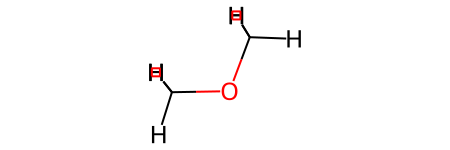

In [227]:
train_dataset.X[6]

In [233]:
train_dataset.y[6]

array([3.42174801])

(array([ 307.,  767., 1584., 1515.,  895.,  290.,   73.,   27.,    9.,
           3.]),
 array([-2.33313582, -1.58030898, -0.82748215, -0.07465531,  0.67817152,
         1.43099836,  2.1838252 ,  2.93665203,  3.68947887,  4.4423057 ,
         5.19513254]),
 <BarContainer object of 10 artists>)

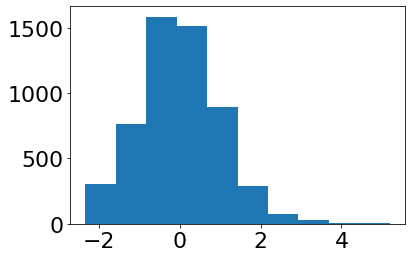

In [234]:
plt.hist(train_dataset.y)

In [231]:
dir(mol)

['AddConformer',
 'ClearComputedProps',
 'ClearProp',
 'Compute2DCoords',
 'ComputeGasteigerCharges',
 'Debug',
 'GetAromaticAtoms',
 'GetAtomWithIdx',
 'GetAtoms',
 'GetAtomsMatchingQuery',
 'GetBondBetweenAtoms',
 'GetBondWithIdx',
 'GetBonds',
 'GetBoolProp',
 'GetConformer',
 'GetConformers',
 'GetDoubleProp',
 'GetIntProp',
 'GetNumAtoms',
 'GetNumBonds',
 'GetNumConformers',
 'GetNumHeavyAtoms',
 'GetProp',
 'GetPropNames',
 'GetPropsAsDict',
 'GetRingInfo',
 'GetStereoGroups',
 'GetSubstructMatch',
 'GetSubstructMatches',
 'GetUnsignedProp',
 'HasProp',
 'HasSubstructMatch',
 'NeedsUpdatePropertyCache',
 'RemoveAllConformers',
 'RemoveConformer',
 'SetBoolProp',
 'SetDoubleProp',
 'SetIntProp',
 'SetProp',
 'SetUnsignedProp',
 'ToBinary',
 'UpdatePropertyCache',
 '__DebugMol',
 '__GetSubstructMatch',
 '__GetSubstructMatches',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',


In [229]:
[x for x in test_dataset.y[:5]]

[array([1.64827302]),
 array([1.04764699]),
 array([0.16434681]),
 array([1.36740798]),
 array([-1.65924065])]

In [320]:
# we're only going to use a small dataset for testing the code here!
my_orig_dataset=test_dataset
num_of_molecules = len(test_dataset)
orig_test_dataset = test_dataset

(array([  83.,  442., 1058., 1664., 1434.,  617.,  134.,   28.,    7.,
           3.]),
 array([-2.9553281 , -2.15650867, -1.35768925, -0.55886982,  0.23994961,
         1.03876903,  1.83758846,  2.63640789,  3.43522731,  4.23404674,
         5.03286617]),
 <BarContainer object of 10 artists>)

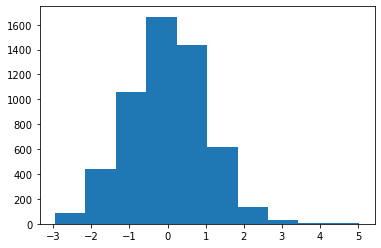

In [17]:
plt.hist(train_dataset.y)

In [18]:
sklearn.model_selection.StratifiedShuffleSplit(n_splits=10, test_size=None, train_size=None, random_state=None)

NameError: name 'sklearn' is not defined

In [180]:
my_dataset

<NumpyDataset X.shape: (684, 18), y.shape: (684, 1), w.shape: (684, 1), ids: [0 1 2 ... 681 682 683], task_names: [0]>

# 2. Create topological features dataset

This makes the topological features.

In [20]:
topol_feat_list, topol_feat_mat = h.make_topological_features_from_deepchem(
    my_dataset,
    file_type='dc',
    verbose=False,
    num_of_molecules = num_of_molecules,
    num_of_features = 18,
    data_dir='',
    do_specified_range=False,
    selected_range=[])

Doing 18 (3 x 6) topology features:
Persistence entropy
number of points
{'metric': 'bottleneck'}
{'metric': 'wasserstein'}
{'metric': 'landscape'}
{'metric': 'persistence_image'}
Got to Molecule no.  0
Got to Molecule no.  1
Got to Molecule no.  2
Got to Molecule no.  3
Got to Molecule no.  4
Got to Molecule no.  5
Got to Molecule no.  6
Got to Molecule no.  7
Got to Molecule no.  8
Got to Molecule no.  9
Got to Molecule no.  10
Got to Molecule no.  11
Got to Molecule no.  12
Got to Molecule no.  13
Got to Molecule no.  14
Got to Molecule no.  15
Got to Molecule no.  16
Got to Molecule no.  17
Got to Molecule no.  18
Got to Molecule no.  19
Got to Molecule no.  20
Got to Molecule no.  21
Got to Molecule no.  22
Got to Molecule no.  23
Got to Molecule no.  24
Got to Molecule no.  25
Got to Molecule no.  26
Got to Molecule no.  27
Got to Molecule no.  28
Got to Molecule no.  29
Got to Molecule no.  30
Got to Molecule no.  31
Got to Molecule no.  32
Got to Molecule no.  33
Got to Molecul

Got to Molecule no.  325
Got to Molecule no.  326
Got to Molecule no.  327
Got to Molecule no.  328
Got to Molecule no.  329
Got to Molecule no.  330
Got to Molecule no.  331
Got to Molecule no.  332
Got to Molecule no.  333
Got to Molecule no.  334
Got to Molecule no.  335
Got to Molecule no.  336
Got to Molecule no.  337
Got to Molecule no.  338
Got to Molecule no.  339
Got to Molecule no.  340
Got to Molecule no.  341
Got to Molecule no.  342
Got to Molecule no.  343
Got to Molecule no.  344
Got to Molecule no.  345
Got to Molecule no.  346
Got to Molecule no.  347
Got to Molecule no.  348
Got to Molecule no.  349
Got to Molecule no.  350
Got to Molecule no.  351
Got to Molecule no.  352
Got to Molecule no.  353
Got to Molecule no.  354
Got to Molecule no.  355
Got to Molecule no.  356
Got to Molecule no.  357
Got to Molecule no.  358
Got to Molecule no.  359
Got to Molecule no.  360
Got to Molecule no.  361
Got to Molecule no.  362
Got to Molecule no.  363
Got to Molecule no.  364


Got to Molecule no.  653
Got to Molecule no.  654
Got to Molecule no.  655
Got to Molecule no.  656
Got to Molecule no.  657
Got to Molecule no.  658
Got to Molecule no.  659
Got to Molecule no.  660
Got to Molecule no.  661
Got to Molecule no.  662
Got to Molecule no.  663
Got to Molecule no.  664
Got to Molecule no.  665
Got to Molecule no.  666
Got to Molecule no.  667
Got to Molecule no.  668
Got to Molecule no.  669
Got to Molecule no.  670
Got to Molecule no.  671
Got to Molecule no.  672
Got to Molecule no.  673
Got to Molecule no.  674
Got to Molecule no.  675
Got to Molecule no.  676
Got to Molecule no.  677
Got to Molecule no.  678
Got to Molecule no.  679
Got to Molecule no.  680
Got to Molecule no.  681
Got to Molecule no.  682
Got to Molecule no.  683


We use the np.array version of topol as **X**. And make a nice dataframe for **y**.

In [208]:
topol_feat_list

[[0.9307415732161114,
  -1.0,
  -1.0,
  9.0,
  0.0,
  0.0,
  0.7281064391136169,
  0.0,
  0.0,
  1.7659457127943023,
  0.0,
  0.0,
  0.5072528799546663,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.9162498389268101,
  -1.0,
  -1.0,
  9.0,
  0.0,
  0.0,
  0.7433947324752808,
  0.0,
  0.0,
  1.832363056802841,
  0.0,
  0.0,
  0.5233128908418753,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.9112895196520147,
  -1.0,
  -1.0,
  7.0,
  0.0,
  0.0,
  0.7381860017776489,
  0.0,
  0.0,
  1.5979578264836751,
  0.0,
  0.0,
  0.5178225056269861,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.9172479626723182,
  -1.0,
  -1.0,
  8.0,
  0.0,
  0.0,
  0.7480289936065674,
  0.0,
  0.0,
  1.7047481966808946,
  0.0,
  0.0,
  0.5282139430163701,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.9294906561624873,
  -1.0,
  -1.0,
  11.0,
  0.0,
  0.0,
  0.7470642924308777,
  0.0,
  0.0,
  1.9885002133503422,
  0.0,
  0.0,
  0.527192449955354,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.9107767526888315,
  -1.0,
  -1.0,
  8.0,
  0.0,
  0.

In [22]:
temp_df = pd.DataFrame(my_dataset.X, colum)
#'L_bottle_1', 'L_bottle_2', 'L_bottle_3', 'L_landsc_1', 'L_landsc_2', 'L_landsc_3', 'L_no_p_1', 'L_no_p_2', 'L_no_p_3', 'L_pers_S_1', 'L_pers_S_2', 'L_pers_S_3', 'L_pers_img_1', 'L_pers_img_2', 'L_pers_img_3', 'L_wasser_1', 'L_wasser_2', 'L_wasser_3', 

NameError: name 'colum' is not defined

In [315]:
len(y_data)

547

In [311]:
X_data = topol_feat_mat
y_data = pd.DataFrame(my_dataset.y, columns=tasks)
len(y_data)
y_data

,u0_atom
0,-901.637520
1,-982.979168
2,-861.974819
3,-847.782036
4,-1187.677451
...,...
542,-1466.097162
543,-1874.979783
544,-1550.601547
545,-1381.592777


# Check it all works with a random forest

In [121]:
(train_scores,test_scores) = h.run_repeated_RF_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_estimators=100,
    test_set_size=10,
    validate_set_size=10)

out=h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')
(min_train_RF_large, mean_train_RF_large, std_error_train_RF_large, max_train_RF_large,
                min_test_RF_large, mean_test_RF_large, std_error_test_RF_large, max_test_RF_large)=out
RF_large_train_scores=train_scores
RF_large_test_scores=test_scores

C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed

training: 	 0.853 <	 0.859. +/- 0.000846 	< 0.863 
testing: 	 -0.388 <	 0.0739. +/- 0.0902 	< 0.503 


In [122]:
results_list = []

In [123]:
egg = ['Rf'] + [x for x in out][:4]
egg = egg + [0,0,0,0] # as no validate
egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

['Rf',
 0.8532510425853724,
 0.8590170998978623,
 0.0008461307196919371,
 0.8633085169740403,
 0,
 0,
 0,
 0,
 -0.3876817689717913,
 0.07389628031425594,
 0.09020549705468985,
 0.5029298001478901]

## Run with my keras model tests

NTS you may want to change this function so that it returns the validate stats as well!
**!! update helper functions with the one below!!**

This is run on the X and y data you made, i.e. it knows nothing about the chemistry and is just the topological features

In [131]:
def run_repeated_keras_NN_tests(
    X_data,
    y_data,
    keras_model=None,
    num_of_repeats=10,
    num_of_epochs=100,
    test_set_size=int(num_of_molecules*0.1),
    validate_set_size=int(num_of_molecules*0.1),
    metric_1=dc.metrics.Metric(dc.metrics.pearson_r2_score),
    metric2 = dc.metrics.Metric(dc.metrics.mae_score)
    ):

    num_of_proteins = len(X_data)
    size_of_output = len(y_data.columns)

    train_scores_r2=[]
    test_scores_r2=[]
    train_scores_mae=[]
    test_scores_mae=[]

    for trial in range(num_of_repeats):
        (train_X_data, ###
         train_y_data,
         test_X_data,
         test_y_data,
         validate_X_data,
         validate_y_data) = h.set_up_train_test_validate(
            X_data,
            y_data,
            test_set_size=test_set_size,
            validate_set_size=validate_set_size,
            verbose=True)
        # put data into a dataset for input to keras
        train_dataset=dc.data.NumpyDataset(train_X_data, train_y_data)
        test_dataset=dc.data.NumpyDataset(test_X_data, test_y_data)
        # choose metric(s)
        metric1 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
        metric2 = dc.metrics.Metric(dc.metrics.mae_score)
        # make deepchem model from keras model
        if keras_model == None:
            keras_model = h.create_keras_model(size_of_output=size_of_output)
        model = dc.models.KerasModel(keras_model, dc.models.losses.L2Loss())
        # fit it
        model.fit(train_dataset, nb_epoch=num_of_epochs)
        train_score = model.evaluate(train_dataset, [metric1, metric2])
        test_score = model.evaluate(test_dataset, [metric1, metric2])
        train_score_r2 = train_score['pearson_r2_score']
        test_score_r2 = test_score['pearson_r2_score']
        train_score_mae = train_score['mae_score']
        test_score_mae = test_score['mae_score']
        print('R2 error\ttrain {:.3}, \t test: {:.3}'.format(train_score_r2, test_score_r2))
        print('MAE error\ttrain {:.3}, \t test: {:.3}'.format(train_score_mae, test_score_mae))
        train_scores_r2.append(train_score_r2)
        test_scores_r2.append(test_score_r2)
        train_scores_mae.append(train_score_mae)
        test_scores_mae.append(test_score_mae)

    print(train_scores_r2)
    print(test_scores_r2)
    out=(train_scores_r2, test_scores_r2, train_scores_mae, test_scores_mae)
    return out

In [132]:
keras_model = h.create_keras_model()
out=run_repeated_keras_NN_tests(
    X_data,
    y_data,
    keras_model=keras_model,
    num_of_repeats=5,
    num_of_epochs=100,
    test_set_size=int(num_of_molecules*0.1),
    validate_set_size=int(num_of_molecules*0.1))

(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

Test set indices:
[255   1  60 548 235 397 578  85  80 144 510 408  99 215  78 494 391 449
 514 537 159 489  15 526 529 533 675 539 238 570  19 183 580 234 227 360
 307 394 129 641 679 455 384 562 377 624 663 561  29 164 417 612 182 585
 188  86 228 567 653 566 358 600 438 611  69 584 130 151]
Validation set indices:
[350 582 622 624 660 421 642 289 290 415 190 213 460 312 126 334 645  23
   5 251 677 644 169 256  66 658 343 163 401 510 179 632 451 128 454 659
  19 113 119 544 285 280 670 463 355 427 376 519 602 497 386 207 429 210
 403 657  44 537 168 367 174  22 635 538 470 221 673 320]
R2 error	train 0.0792, 	 test: 0.016
MAE error	train 0.736, 	 test: 0.819
Test set indices:
[ 36  45 455 393  78 391 461  71 435 668 119 471 191 358 264  33  49 490
  85 137 169 296 491 657 419 446 386 120 575 268 518 426 457 545 635 577
 542  25 104 142 665 537  86 615 102  53 496 422 508 290 640 519 294 240
 554 213 450  54 144 567 521 263 184 305 299 550 216 103]
Validation set indices:
[178 271 20

R2 error	train 0.121, 	 test: 0.068
MAE error	train 0.695, 	 test: 0.816
Test set indices:
[503 238 579 545 596  83  41 305 598 239 659 358 645 211 275 482 414 631
  65 295  88 396 132 101  94 648 548 213  38 636 637 673 623 571 386 463
 255  92 672 175 657 658 561  97 528 654 331 600  47 641  29   5 653 288
 470 617 362 462 554 467 403 538 508  32 200 341 619 484]
Validation set indices:
[387 401 604  75 352   2 169 447 207  63 171 364 639  40  49 498 223 303
 286 121  43 313 298 449 115 666 480 165 456  94 153 611 173 311 299 543
 459 637 649 318 201 590 390  57 545 585 204 138 244 277 437  26 561 236
 362  16  53 504 442 542 217 333 262 216 507  39 450 506]
R2 error	train 0.129, 	 test: 0.00737
MAE error	train 0.702, 	 test: 0.786
Test set indices:
[211 243 126 638 642  51 535 487 442  39 593 549  55 326  32 247 650 541
   8 256 155 263 297 658 504 580  60 199 121 519  69 260 682 572 400 600
 521 498 634 414 563 514 123 232 354 317 525 620 194 310 331  99 500 559
 325 146 195 478 57

In [133]:
results_dataframe = pd.DataFrame(columns=['Exp name', 
                        'train_min', 'train_mean', 'train_std', 'train_max',
                        'valid_min', 'valid_mean', 'valid_std', 'valid_max',
                        'test_min', 'test_mean', 'test_std', 'test_max',])

In [134]:
out=h.nice_stats_outputter(
    train_scores_rmse, 
    test_scores_rmse, 
    validate_scores='')
(min_train_keras, mean_train_keras, std_train_error_keras, max_train_keras,
                min_test_keras, mean_test_keras, std_error_test_keras, max_test_keras)=out
#RF_large_train_scores=train_scores
#RF_large_test_scores=test_scores

training: 	 0.695 <	 0.713. +/- 0.00706 	< 0.736 
testing: 	 0.612 <	 0.755. +/- 0.0343 	< 0.819 


In [135]:
results_list

[['Rf',
  0.8532510425853724,
  0.8590170998978623,
  0.0008461307196919371,
  0.8633085169740403,
  0,
  0,
  0,
  0,
  -0.3876817689717913,
  0.07389628031425594,
  0.09020549705468985,
  0.5029298001478901]]

In [136]:
egg = ['keras'] + [x for x in out][:4]
egg = egg + [0,0,0,0] # as no validate
egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

['keras',
 0.6954433,
 0.71341825,
 0.007055882669863554,
 0.73555386,
 0,
 0,
 0,
 0,
 0.6120841,
 0.7554011,
 0.034264648298858065,
 0.8185439]

## Using DeepChem's Multitask regressor

We have to create new dataset in the format that DeepChem expects.

IndexError: index 547 is out of bounds for axis 0 with size 547

,u0_atom
0,-901.637520
1,-982.979168
2,-861.974819
3,-847.782036
4,-1187.677451
...,...
542,-1466.097162
543,-1874.979783
544,-1550.601547
545,-1381.592777


In [321]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y)
print(my_dataset)

<NumpyDataset X.shape: (684, 18), y.shape: (684, 1), w.shape: (684, 1), ids: [0 1 2 ... 681 682 683], task_names: [0]>


In [322]:
my_dataset.to_dataframe().head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,y,w,ids
0,0.930742,-1.0,-1.0,9.0,0.0,0.0,0.728106,0.0,0.0,1.765946,...,0.0,0.507253,0.0,0.0,0.0,0.0,0.0,-1189.1,1.0,0
1,0.916250,-1.0,-1.0,9.0,0.0,0.0,0.743395,0.0,0.0,1.832363,...,0.0,0.523313,0.0,0.0,0.0,0.0,0.0,-1321.9,1.0,1
2,0.911290,-1.0,-1.0,7.0,0.0,0.0,0.738186,0.0,0.0,1.597958,...,0.0,0.517823,0.0,0.0,0.0,0.0,0.0,-1517.2,1.0,2
3,0.917248,-1.0,-1.0,8.0,0.0,0.0,0.748029,0.0,0.0,1.704748,...,0.0,0.528214,0.0,0.0,0.0,0.0,0.0,-1251.2,1.0,3
4,0.929491,-1.0,-1.0,11.0,0.0,0.0,0.747064,0.0,0.0,1.988500,...,0.0,0.527192,0.0,0.0,0.0,0.0,0.0,-1920.4,1.0,4


In [212]:
meh = my_dataset.to_dataframe()
meh.to_csv("small_test_qm7_data_2.csv")

In [213]:
# saving to disc
#import tempfile

#with tempfile.TemporaryDirectory() as data_dir:
#    disk_dataset = dc.data.DiskDataset.from_numpy(X=X, y=y, data_dir=data_dir)
#    print(disk_dataset)

We can use DeepChem's splitter. You need to instantiate it as an object first.

In [289]:
transformers[0]

In [341]:
tp_norm_transformer = dc.trans.NormalizationTransformer

In [349]:
my_dataset.y

array([[-1189.1 ],
       [-1321.9 ],
       [-1517.2 ],
       [-1251.2 ],
       [-1920.4 ],
       [-2189.4 ],
       [-1383.1 ],
       [-1515.6 ],
       [-1257.5 ],
       [-1389.7 ],
       [-1458.1 ],
       [-1590.5 ],
       [-1348.2 ],
       [-1479.6 ],
       [-1236.2 ],
       [-1361.9 ],
       [-1916.8 ],
       [-1278.9 ],
       [-1148.6 ],
       [-1335.  ],
       [-1192.9 ],
       [-1461.5 ],
       [-1324.2 ],
       [-1246.7 ],
       [-1376.5 ],
       [-1509.5 ],
       [-1713.9 ],
       [-1937.3 ],
       [-1583.6 ],
       [-1707.2 ],
       [-1578.  ],
       [-1712.3 ],
       [-1583.1 ],
       [-1279.4 ],
       [-1442.2 ],
       [-1282.1 ],
       [-1571.  ],
       [-1408.7 ],
       [-1555.2 ],
       [-1567.7 ],
       [-1568.2 ],
       [-1411.9 ],
       [-1162.  ],
       [-1328.7 ],
       [-1156.8 ],
       [-1162.8 ],
       [-1326.5 ],
       [-1158.5 ],
       [-1472.1 ],
       [-1406.2 ],
       [-1454.4 ],
       [-1297.1 ],
       [-145

In [350]:
from deepchem.trans import NormalizationTransformer
new_transformer = NormalizationTransformer(
    transform_y=True,
    dataset=my_dataset)
normed_dataset = new_transformer.transform(my_dataset)

In [361]:
# didn't work, also its only 600 points!
Splitter_Object = dc.splits.RandomSplitter()
train_dataset_tf, valid_dataset_tf, test_dataset_tf = Splitter_Object.train_valid_test_split(
    dataset=normed_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)

#train_dataset = dc.data.NumpyDataset(X=X_data[:547], y=y_data[:547])
#valid_dataset = dc.data.NumpyDataset(X=X_data[547:615], y=y_data[547:615])
#test_dataset = dc.data.NumpyDataset(X=X_data[615:], y=y_data[615:])

In [352]:
valid_dataset_tf.X[0]

array([ 0.92665838, -1.        , -1.        , 13.        ,  0.        ,
        0.        ,  0.76611316,  0.        ,  0.        ,  2.20699153,
        0.        ,  0.        ,  0.54748421,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [353]:
valid_dataset_tf.y[0]

array([0.02855044])

In [216]:
len(train_dataset)

547

In [217]:
len(valid_dataset)

68

In [218]:
684-69

615

In [219]:
684-68-69

547

For this problem we're using the MAE which is averaged across all tasks.

This bit of optimises the hyperparameters by running a few epochs of several models.

In [220]:
tasks

['u0_atom']

### Error : this doesn't work with QM7

Not sure why, I think their code might need the dataset to be normalised or something. Will use PCA when I do the larger datasets.

In [354]:
train_scores, validate_scores, test_scores = [],[],[]
for i in range(5):
    model = dc.models.MultitaskRegressor(n_tasks=len(tasks),
                                          n_features=18,
                                          layer_sizes=[1000,1000],
                                          dropouts=0.4,
                                          learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_tf, 1000, metric)
    model.fit(train_dataset_tf, nb_epoch=5, callbacks=callback)

    # line below returns a dictionary
    train_scores.append(model.evaluate(train_dataset_tf, 
                                       metric, 
                                       transformers=[new_transformer])['mae_score'])
    validate_scores.append(model.evaluate(valid_dataset_tf, 
                                          metric, 
                                          transformers=[new_transformer])['mae_score'])
    test_scores.append(model.evaluate(test_dataset_tf, 
                                      metric, 
                                      transformers=[new_transformer])['mae_score'])

In [363]:
train_dataset_tf

<NumpyDataset X.shape: (547, 18), y.shape: (547, 1), w.shape: (547, 1), ids: [320 88 92 ... 240 473 650], task_names: [0]>

In [367]:
model.evaluate(
    train_dataset_tf, 
    metric, 
    transformers=[new_transformer])['mae_score']

AttributeError: 'function' object has no attribute 'transform_y'

In [429]:
save_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
qm7_df=pd.read_csv(os.path.join(save_dir,'qm7.csv'))

In [430]:
qm7_df['smiles']

0                                     C([H])([H])([H])[H]
1                            [H]C([H])([H])C([H])([H])[H]
2                                     [H]C([H])=C([H])[H]
3                                               [H]C#C[H]
4                           [H]OC([H])([H])C([H])([H])[H]
                              ...                        
6829    [H]C(=C(C#N)C([H])([H])[H])C([H])([H])C([H])([...
6830    [H]C(=C([H])C([H])(N([H])[H])C([H])([H])[H])C(...
6831    [H]C(=C([H])C([H])([H])C([H])([H])[H])C([H])([...
6832    [H]C([H])=C(C([H])([H])C([H])([H])[H])C([H])([...
6833    [H]C([H])=C(C([H])([H])C([H])([H])[H])C([H])(N...
Name: smiles, Length: 6834, dtype: object

In [444]:
out_file_name='qm7_topological_features.hdf5'
fh = h5py.File(os.path.join(save_dir,out_file_name), 'r+')
# num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

In [445]:
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	5
num_of_molecules is:	 5
num_of_augments is:	1


In [446]:
fh.keys()

<KeysViewHDF5 ['PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'u0_atom', 'wasser_1', 'wasser_2', 'wasser_3']>

In [449]:
fh['SMILES'][:]

array(['C([H])([H])([H])[H]', '[H]C([H])([H])C([H])([H])[H]',
       '[H]C([H])=C([H])[H]', '[H]C#C[H]',
       '[H]OC([H])([H])C([H])([H])[H]'], dtype=object)

In [441]:
fh.close()

In [395]:
with open(os.path.join(save_dir,'x_data_qm7.csv'), 'r') as read_obj:
    # pass the file object to reader() to get the reader object
    csv_reader = reader(read_obj)
    # Pass reader object to list() to get a list of lists
    topl_QM7_all_list = list(csv_reader)
    print(topl_QM7_all_list)

[['0.9184249843631107', '-1.0', '-1.0', '8.0', '0.0', '0.0', '0.7513014674186707', '0.0', '0.0', '1.7002029706401025', '0.0', '0.0', '0.5316839731862255', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.9290760431915012', '-1.0', '-1.0', '10.0', '0.0', '0.0', '0.7596912980079651', '0.0', '0.0', '1.8846063134830802', '0.0', '0.0', '0.5406148130246317', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.9258654328369503', '-1.0', '-1.0', '8.0', '0.0', '0.0', '0.7463760375976562', '0.0', '0.0', '1.6699859695222437', '0.0', '0.0', '0.5264640805780114', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.916159124012478', '-0.0', '-1.0', '13.0', '1.0', '0.0', '0.7629647850990295', '0.26407337188720703', '0.0', '2.2776522658267333', '0.26407337188720703', '0.0', '0.5441128140695314', '0.11079473677689328', '0.0', '15.409187550579658', '0.0', '0.0'], ['0.9288800152791311', '-0.0', '-1.0', '17.0', '1.0', '0.0', '0.7669416666030884', '0.26268619298934937', '0.0', '2.5589559848354684', '0.26268619298934937', '0.0', '0.5483725

In [402]:
with open(os.path.join(save_dir,'x_data_qm7.csv'), 'r') as read_obj:
    # pass the file object to reader() to get the reader object
    csv_reader = reader(read_obj)
    # Pass reader object to list() to get a list of lists
    topl_QM7_all_list = list(csv_reader)
    print(topl_QM7_all_list)

[['0.9279603975398141', '-1.0', '-1.0', '7.0', '0.0', '0.0', '0.7559609413146973', '0.0', '0.0', '1.5385352730036481', '0.0', '0.0', '0.5366377863058334', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.9246337470178079', '-1.0', '-1.0', '5.0', '0.0', '0.0', '0.6678999662399292', '0.0', '0.0', '1.274550272602545', '0.0', '0.0', '0.44565557727796035', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.9115465342353081', '-1.0', '-1.0', '3.0', '0.0', '0.0', '0.6000999808311462', '0.0', '0.0', '0.9633162978591863', '0.0', '0.0', '0.37954880907487754', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.9241454896888341', '-1.0', '-1.0', '8.0', '0.0', '0.0', '0.7573524713516235', '0.0', '0.0', '1.6765302279363246', '0.0', '0.0', '0.5381201865762776', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.9100622246880495', '-1.0', '-1.0', '6.0', '0.0', '0.0', '0.7478034496307373', '0.0', '0.0', '1.46143401039616', '0.0', '0.0', '0.5279750622517196', '0.0', '0.0', '0.0', '0.0', '0.0'], ['0.9246604758988958', '-1.0', '-1.0', '8.0', '0.0

In [404]:
pca = PCA(n_components=18)
principalComponents_large = pca.fit_transform(topl_QM7_all_list)

In [405]:

principalComponents_large

array([[-1.15707849e+01,  4.20296330e-01, -7.87976497e-01,
         7.04300406e-02,  4.99439481e-02,  7.33958971e-03,
         3.19121369e-02, -3.09612881e-02, -3.46718379e-02,
        -5.36567801e-03,  1.59913369e-03,  5.31559848e-03,
         1.08389515e-04,  2.69456608e-17,  8.34411132e-19,
        -3.09343124e-19, -9.56055169e-20, -0.00000000e+00],
       [-1.22553297e+01, -1.02268016e+00, -2.01945683e+00,
         8.44455012e-02,  1.25279968e-01,  5.81978463e-02,
        -2.27316813e-02,  4.07632613e-02,  7.47945523e-03,
        -5.64399840e-03, -2.26688763e-03,  3.74048372e-04,
         4.53822327e-04,  2.50143732e-17,  1.03082969e-18,
         6.28355699e-20,  5.34574357e-19,  0.00000000e+00],
       [-1.29415338e+01, -2.46860739e+00, -3.25410052e+00,
         9.89155246e-02,  2.02786425e-01,  1.17984655e-01,
        -7.16252649e-02,  1.28266617e-01, -3.08507711e-03,
         5.51357353e-03, -7.16387936e-04,  7.33411216e-04,
        -5.09738085e-04,  4.01462633e-17, -4.78993781e

In [411]:
mol_idx = 0
(a,b,c,
 d,e,f,
 g,h,i,
 j,k,l,
 m,n,o,
 p,q,r)=topl_QM7_all_list[mol_idx]

In [415]:
np.array(topl_QM7_all_list[mol_idx])

array(['0.9279603975398141', '-1.0', '-1.0', '7.0', '0.0', '0.0',
       '0.7559609413146973', '0.0', '0.0', '1.5385352730036481', '0.0',
       '0.0', '0.5366377863058334', '0.0', '0.0', '0.0', '0.0', '0.0'],
      dtype='<U18')

In [389]:
topl_features_df

,0.9184249843631107,-1.0,-1.0.1,8.0,0.0,0.0.1,0.7513014674186707,0.0.2,0.0.3,1.7002029706401025,0.0.4,0.0.5,0.5316839731862255,0.0.6,0.0.7,0.0.8,0.0.9,0.0.10
0,0.929076,-1.000000,-1.0,10.0,0.0,0.0,0.759691,0.000000,0.0,1.884606,0.000000,0.0,0.540615,0.000000,0.0,0.000000,0.000000,0.0
1,0.925865,-1.000000,-1.0,8.0,0.0,0.0,0.746376,0.000000,0.0,1.669986,0.000000,0.0,0.526464,0.000000,0.0,0.000000,0.000000,0.0
2,0.916159,-0.000000,-1.0,13.0,1.0,0.0,0.762965,0.264073,0.0,2.277652,0.264073,0.0,0.544113,0.110795,0.0,15.409188,0.000000,0.0
3,0.928880,-0.000000,-1.0,17.0,1.0,0.0,0.766942,0.262686,0.0,2.558956,0.262686,0.0,0.548373,0.109923,0.0,22.991995,0.000000,0.0
4,0.916761,-0.000000,-1.0,13.0,1.0,0.0,0.767301,0.259806,0.0,2.273546,0.259806,0.0,0.548758,0.108120,0.0,15.493727,0.000000,0.0
5,0.898402,4.461162,-1.0,10.0,2.0,0.0,0.853633,0.321936,0.0,2.048776,0.414699,0.0,0.643930,0.182612,0.0,13.535225,2.080455,0.0
6,0.894668,3.185553,-1.0,10.0,2.0,0.0,0.877812,0.363131,0.0,2.071013,0.443977,0.0,0.671482,0.205563,0.0,13.075715,2.129784,0.0
7,0.886037,5.007814,-1.0,9.0,2.0,0.0,0.860992,0.319836,0.0,1.987329,0.408191,0.0,0.652275,0.178702,0.0,12.178352,2.136449,0.0


In [388]:
fh.close()

In [400]:
with open(os.path.join(save_dir,'x_data_qm7.csv'), 'r') as read_obj:
    # pass the file object to reader() to get the reader object
    csv_reader = reader(read_obj)
    # Pass reader object to list() to get a list of lists
    topl_QM7_all_list = list(csv_reader)
    print(topl_QM7_all_list)

[]


In [356]:
out=h.nice_stats_outputter(
    train_scores=train_scores, 
    test_scores=test_scores, 
    validate_scores=validate_scores)

training: 	 1.78e+02 <	 2.14e+02. +/- 10.6 	< 2.4e+02 
validation: 	 1.88e+02 <	 2.29e+02. +/- 12.6 	< 2.55e+02 
testing: 	 1.69e+02 <	 2.07e+02. +/- 10.6 	< 2.37e+02 


In [281]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [len(my_dataset.X[0])],
    'layer_sizes': [[500], 
                    [1000], 
                    [1000, 1000], 
                    [1000,500,500,500,200], 
                    [1000, 500, 500, 200]],
    'dropouts': [0.2, 0.3, 0.4, 0.5],
    'learning_rate': [0.01, 0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
# We want to know the RMS, averaged across tasks
metric = dc.metrics.Metric(dc.metrics.mae_score)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
        params_dict, 
    train_dataset_tf, 
    valid_dataset_tf, 
    metric, 
    transformers)

KeyboardInterrupt: 

In [252]:
all_results

{'_dropouts_0.200000_layer_sizes[500]_learning_rate_0.010000_n_features_18_n_tasks_1': 55698.682005683746,
 '_dropouts_0.200000_layer_sizes[500]_learning_rate_0.001000_n_features_18_n_tasks_1': 283142.4122352814,
 '_dropouts_0.200000_layer_sizes[500]_learning_rate_0.000100_n_features_18_n_tasks_1': 303307.7239982602,
 '_dropouts_0.300000_layer_sizes[500]_learning_rate_0.010000_n_features_18_n_tasks_1': 55045.65059701931,
 '_dropouts_0.300000_layer_sizes[500]_learning_rate_0.001000_n_features_18_n_tasks_1': 283374.17056804785,
 '_dropouts_0.300000_layer_sizes[500]_learning_rate_0.000100_n_features_18_n_tasks_1': 303454.27984161273,
 '_dropouts_0.400000_layer_sizes[500]_learning_rate_0.010000_n_features_18_n_tasks_1': 54950.12778414173,
 '_dropouts_0.400000_layer_sizes[500]_learning_rate_0.001000_n_features_18_n_tasks_1': 283364.20587454847,
 '_dropouts_0.400000_layer_sizes[500]_learning_rate_0.000100_n_features_18_n_tasks_1': 303402.2260189425,
 '_dropouts_0.500000_layer_sizes[500]_lear

In [253]:
best_hyperparams

(1, 18, [500], 0.3, 0.0001)

Now we copy the hyperparameters in and run the model with early stopping. 

In [263]:
train_dataset.X

array([[ 0.93074157, -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.91624984, -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.91128952, -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.93057657, -0.        , -1.        , ..., 21.62444685,
         0.        ,  0.        ],
       [ 0.92832009,  3.71377231, -1.        , ..., 14.71307173,
         2.07418904,  0.        ],
       [ 0.92524804, -0.        , -1.        , ..., 20.31082496,
         0.        ,  0.        ]])

In [267]:
train_scores, validate_scores, test_scores = [],[],[]
for i in range(5):
    model = dc.models.MultitaskRegressor(n_tasks=len(tasks),
                                          n_features=18,
                                          layer_sizes=[1000,1000],
                                          dropouts=0.4,
                                          learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset, 1000, metric)
    model.fit(train_dataset, nb_epoch=50, callbacks=callback)

    # line below returns a dictionary
    train_scores.append(model.evaluate(train_dataset, metric, transformers=transformers)['mae_score'])
    validate_scores.append(model.evaluate(valid_dataset, metric, transformers=transformers)['mae_score'])
    test_scores.append(model.evaluate(test_dataset, metric, transformers=transformers)['mae_score'])

IndexError: index 63 is out of bounds for axis 0 with size 18

In [330]:
model.evaluate(train_dataset_tf, metric, transformers=transformer)

TypeError: float() argument must be a string or a number, not 'Mol'

In [333]:
out=h.nice_stats_outputter(
    train_scores=train_scores, 
    test_scores=test_scores, 
    validate_scores=validate_scores)


training: 	 3.82e+04 <	 4.02e+04. +/- 9.74e+02 	< 4.4e+04 
validation: 	 3.95e+04 <	 4.18e+04. +/- 9.69e+02 	< 4.5e+04 
testing: 	 3.52e+04 <	 3.78e+04. +/- 1.25e+03 	< 4.28e+04 


In [334]:
egg = ['topol_f'] + [x for x in out]
#egg
#egg = egg + [0,0,0,0] # as no validate
#egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

['topol_f',
 38228.67443629512,
 40168.9238812041,
 973.76844721817,
 43976.150557127774,
 39490.41127681843,
 41832.73224247249,
 968.8261790671904,
 45049.51110530809,
 35240.52565330654,
 37840.96141126818,
 1245.9098966938877,
 42834.00981131804]

# 4. (Extra) Look at the molecules and plot topology stuff

In [268]:
# this should grab a random molecule
mol = test_dataset.X[0]
mol

array([ 0.92604504, -1.        , -1.        , 13.        ,  0.        ,
        0.        ,  0.73768151,  0.        ,  0.        ,  2.21098903,
        0.        ,  0.        ,  0.51729176,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [49]:

print(f"Dataset has {num_of_molecules} molecules")
num_of_features = 18

Dataset has 684 molecules


In [50]:
coords = mol.GetConformer().GetPositions()

AttributeError: 'numpy.ndarray' object has no attribute 'GetConformer'

In [51]:
# Testing the topology stuff - this gives a nice point cloud picture
plot_point_cloud(coords)

NameError: name 'coords' is not defined

In [52]:
## does the topology stuff
# Track connected components, loops, and voids
homology_dimensions = [0, 1, 2]

# Collapse edges to speed up H2 persistence calculation!
persistence = VietorisRipsPersistence(
    metric="euclidean",
    homology_dimensions=homology_dimensions,
    n_jobs=6,
    collapse_edges=True,
)
reshaped_coords=coords[None, :, :]
diagrams_basic = persistence.fit_transform(reshaped_coords)

NameError: name 'coords' is not defined

In [53]:
# makes a nice birth-death diagram
plot_diagram(diagrams_basic[0])

NameError: name 'diagrams_basic' is not defined

In [54]:
train_dataset, valid_dataset, test_dataset = datasets
len(tasks)
f'Compound train/valid/test split: {len(train_dataset)}/{len(valid_dataset)}/{len(test_dataset)}'

'Compound train/valid/test split: 5470/684/684'

In [55]:
train_dataset.X

array([<rdkit.Chem.rdchem.Mol object at 0x0000025206BB04B0>,
       <rdkit.Chem.rdchem.Mol object at 0x0000025206BB0A70>, ...,
       <rdkit.Chem.rdchem.Mol object at 0x0000025206B9B970>], dtype=object)

# 5. DeepChem's models (no topology)

In [155]:
tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
    shard_size=2000, featurizer="ECFP", splitter="stratified")
_, _, small_dataset = datasets
## we're jsut going to use the test dataset here to test the code
splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
  dataset=small_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
)

# We want to know the RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.mae_score)

In [156]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [1024],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'learning_rate': [0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
metric = dc.metrics.Metric(dc.metrics.mae_score)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
        params_dict, train_dataset, valid_dataset, metric, transformers_ECFP)

In [158]:
best_hyperparams

(1, 1024, [1000, 1000], 0.5, 0.0001)

In [165]:
len(valid_dataset.X[0])

1024

In [159]:
train_scores, validate_scores, test_scores = [],[],[]
for i in range(5):
    model = dc.models.MultitaskRegressor(n_tasks=len(tasks),
                                          n_features=1024,
                                          layer_sizes=[1000,1000],
                                          dropouts=0.5,
                                          learning_rate=0.0001)
    callback = dc.models.ValidationCallback(valid_dataset, 1000, metric)
    model.fit(train_dataset, nb_epoch=50, callbacks=callback)

    # line below returns a dictionary
    train_scores.append(
        model.evaluate(
            train_dataset, 
            metric, 
            transformers=transformers_ECFP)['mae_score'])
    validate_scores.append(
        model.evaluate(
            valid_dataset, 
            metric, 
            transformers=transformers_ECFP)['mae_score'])
    test_scores.append(
        model.evaluate(
            test_dataset, 
            metric, 
            transformers=transformers_ECFP)['mae_score'])

In [160]:
model.evaluate(train_dataset, metric, transformers=transformers_ECFP)

{'mae_score': 172.17959002695875}

In [166]:
out=h.nice_stats_outputter(
    train_scores=train_scores, 
    test_scores=test_scores_rmse, 
    validate_scores=validate_scores)

training: 	 1.69e+02 <	 1.7e+02. +/- 0.484 	< 1.72e+02 
validation: 	 1.62e+02 <	 1.64e+02. +/- 0.662 	< 1.66e+02 
testing: 	 0.612 <	 0.755. +/- 0.0343 	< 0.819 


In [167]:
egg = ['ECFP'] + [x for x in out]
#egg
#egg = egg + [0,0,0,0] # as no validate
#egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

['ECFP',
 169.05491048112194,
 170.23269684459615,
 0.48439744724367056,
 172.17959002695875,
 161.88770497572304,
 163.55342925396297,
 0.6620383869477146,
 166.0423842173385,
 0.6120841,
 0.7554011,
 0.034264648298858065,
 0.8185439]

In [168]:
n_layers = 3
model = dc.models.MultitaskRegressor(
    len(tasks),
    n_features=1024,
    layer_sizes=[1000] * n_layers,
    dropouts=[.25] * n_layers,
    weight_init_stddevs=[.02] * n_layers,
    bias_init_consts=[1.] * n_layers,
    learning_rate=.0003,
    weight_decay_penalty=.0001,
    batch_size=100)

In [169]:
model.fit(train_dataset, nb_epoch=5)

3.2210421244303387

In [170]:
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers_ECFP)
assert train_scores['mean-mae_score'] < 10.00
valid_scores = model.evaluate(valid_dataset, [avg_rms],transformers_ECFP)
assert valid_scores['mean-mae_score'] < 10.00
print(valid_scores)
test_scores = model.evaluate(test_dataset, [avg_rms], transformers_ECFP)
assert test_scores['mean-mae_score'] < 10.00
print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

KeyError: 'mean-mae_score'

In [171]:
train_scores

{'mae_score': 206.71572831405578}

### all data for comparison
this in trained on the entire dataset, so should be much better

In [172]:
tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
    shard_size=2000, featurizer="ECFP", splitter="stratified")
# We want to know the RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.mae_score)
train_dataset, valid_dataset, test_dataset = datasets

n_layers = 3
model = dc.models.MultitaskRegressor(
    len(tasks),
    n_features=1024,
    layer_sizes=[1000] * n_layers,
    dropouts=[.25] * n_layers,
    weight_init_stddevs=[.02] * n_layers,
    bias_init_consts=[1.] * n_layers,
    learning_rate=.0003,
    weight_decay_penalty=.0001,
    batch_size=100)

model.fit(train_dataset, nb_epoch=5)

# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers_ECFP)
#assert train_scores['mean-rms_score'] < 10.00
valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers_ECFP)
#assert valid_scores['mean-rms_score'] < 10.00
print(valid_scores)
test_scores = model.evaluate(test_dataset, [avg_rms], transformers_ECFP)
#assert test_scores['mean-rms_score'] < 10.00
print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

{'mae_score': 170.86153284939576}
Train scores average = {'mae_score': 172.8798968699782}
Validate scores average = {'mae_score': 170.86153284939576}
Test scores average = {'mae_score': 181.07376949419847}


# Results

(I ran keras twice somehow).

In [173]:
results_dataframe = pd.DataFrame(results_list, columns=['Exp name', 
                        'train_min', 'train_mean', 'train_std', 'train_max',
                        'valid_min', 'valid_mean', 'valid_std', 'valid_max',
                        'test_min', 'test_mean', 'test_std', 'test_max'])

In [174]:
results_dataframe

,Exp name,train_min,train_mean,train_std,train_max,valid_min,valid_mean,valid_std,valid_max,test_min,test_mean,test_std,test_max
0,Rf,0.853251,0.859017,0.000846,0.863309,0.000000,0.000000,0.000000,0.000000,-0.387682,0.073896,0.090205,0.502930
1,keras,0.695443,0.713418,0.007056,0.735554,0.000000,0.000000,0.000000,0.000000,0.612084,0.755401,0.034265,0.818544
2,ECFP,169.054910,170.232697,0.484397,172.179590,161.887705,163.553429,0.662038,166.042384,0.612084,0.755401,0.034265,0.818544


In [175]:
means = []
stds = []
for i in range(len(results_list)):
    means.append(results_list[i][2])
    means.append(results_list[i][10])
    
stds = []
for i in range(len(results_list)):
    stds.append(results_list[i][3])
    stds.append(results_list[i][11])

In [176]:
labels = results_dataframe['Exp name']
#labels[]
labels = [x for x in labels]

In [177]:
labels

['Rf', 'keras', 'ECFP']

In [178]:
labels = ['Rf', 'keras', 'topol_f', 'ECFP']

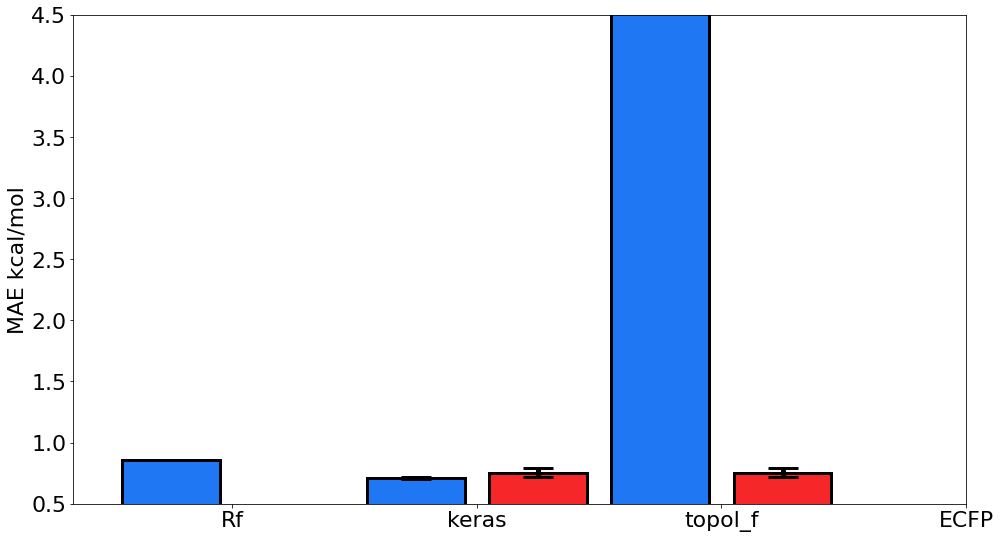

In [179]:
Best=0.053

#data=[dc_NN_MR_small_train_scores_rmse,
#      dc_NN_MR_small_test_scores_rmse,
#      dc_NN_MR_large_train_scores_rmse,
#      dc_NN_MR_large_test_scores_rmse]
      

#x_positions = [1,2,3,4]
# train test
#means=[mean_train_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse]
#stds=[std_error_train_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse]



x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
#plt.fontsize(14)
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
#for i in range(4):
#    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,max(x_positions) + 0.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
plt.xticks([1.5,3.5,5.5,7.5],labels)
plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(results_dir, "2021_10_04_QM7_rmse_all_tests_run2.png"))

## Write up

We use the mean RMSE across all tasks in this work.

## Finding 1. 

Random forest baseline shows that the problem is difficult. The keras model uses the topological features but it not optmised, so gives a benchmark of no optimisation. 

The ECFP was optimised. So using topological features on a naive and unoptimised NN is the same as optimising with ECFP features. 

In [ ]:
Best=0.053

#data=[dc_NN_MR_small_train_scores_rmse,
#      dc_NN_MR_small_test_scores_rmse,
#      dc_NN_MR_large_train_scores_rmse,
#      dc_NN_MR_large_test_scores_rmse]
      

#x_positions = [1,2,3,4]
# train test
#means=[mean_train_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse]
#stds=[std_error_train_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse]

#means = means[:-4]
#stds = stds[:-4]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
#plt.fontsize(14)
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
#for i in range(4):
#    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,max(x_positions) + 0.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
axes.set_ylim([-0.2,1.2])
plt.xticks([1.5,3.5,5.5,7.5],['','','topological features','ECFP'])
axes.set_xlim([4.5,8.5])
plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(results_dir, "2021_10_04_Mae_run3.png"))

## Finding 2.

topol and ECFP results above were training on the same type of NN and both sets of hyperparameters were optimised.

The black dot-dashed line is at 0.053 which is the average RMSE error from using the entire dataset (admittedly no optimisation but life is too short) and ECFPs. 

The bars are train and test from hyperparameter optimised runs using topological features (size 18) or ECFP (size 1024).

**Firstly:** topol features beats ECFP on this dataset

**Secondly** topol features is as good (on this test dataset) as a model trained on the larger dataset! N.B. this dataset is 1/10th of the size of the larger dataset. 

## Graph Conv on QM8

broken from here on!

In [ ]:
tasks, datasets, transformers = dc.molnet.load_qm8(
   shard_size=2000, featurizer="GraphConv", split="random")
_, _, my_dataset = datasets
## we're jsut going to use the test dataset here to test the code
splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
  dataset=my_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
)

# RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
model = dc.models.GraphConvModel(
   len(tasks), batch_size=128, mode='regression')
# Fit trained model
model.fit(train_dataset, nb_epoch=5)
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00

valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00

print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

In [ ]:
splitter = dc.splits.RandomSplitter()
tasks, datasets, transformers = dc.molnet.load_qm8(
   shard_size=2000, featurizer="GraphConv", splitter="random")
train_dataset, valid_dataset, test_dataset = datasets

#train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
#  dataset=my_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
#)
# RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
model = dc.models.GraphConvModel(
   len(tasks), batch_size=128, mode='regression')
# Fit trained model
model.fit(train_dataset, nb_epoch=5)
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00

valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00

print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

In [ ]:
splitter = dc.splits.RandomSplitter()
tasks, datasets, transformers = dc.molnet.load_qm8(
   shard_size=2000, featurizer="GraphConv", splitter="random")
_, _, my_dataset = datasets

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
  dataset=my_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
)
# RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
model = dc.models.GraphConvModel(
   len(tasks), batch_size=128, mode='regression')
# Fit trained model
model.fit(train_dataset, nb_epoch=5)
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00

valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00

print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

In [ ]:
train_dataset